# Session 1 — CNC 밀링머신 이상탐지 실습 노트북

## 실제 가속도 센서 데이터 기반 EDA 및 이상탐지 파이프라인

**데이터**: `h1_data_copy/Dataset/Dataset/` 내 13개 CSV 파일  
**센서**: 3축 가속도 (acc_x, acc_y, acc_z)  
**조건**: 정상(normal, 0x), 채터링(chatter, 1x), 마모(wear, 2x)

> 참고 교재: *Think DSP* | *ML for Imbalanced Data* | *ML for Time-Series with Python*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import (f1_score, recall_score, precision_score,
                             classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE
import os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

## 1. 데이터 로드

In [2]:
DATA_DIR = 'h1_data_copy/Dataset/Dataset/'

# 라벨 → 조건 매핑
condition_map = {}
for i in range(3):
    condition_map[f'label_0{i}.csv'] = 'normal'
for i in [1, 2]:
    condition_map[f'label_1{i}.csv'] = 'chatter'
for i in range(7):
    condition_map[f'label_2{i}.csv'] = 'wear'

# 절대경로로 변환 (노트북 위치 기준)
import os
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('h1_cnc_anomaly_detection.ipynb'))
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join(NOTEBOOK_DIR, DATA_DIR)

print(f"Data directory: {DATA_DIR}")
print(f"Exists: {os.path.exists(DATA_DIR)}")

# 모든 파일 로드
all_dfs = []
for fname, cond in condition_map.items():
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        df['condition'] = cond
        df['source'] = fname.replace('.csv', '')
        all_dfs.append(df)
        print(f"  Loaded {fname}: {len(df):,} rows ({cond})")

data = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal samples: {len(data):,}")
print(f"\nCondition distribution:")
print(data['condition'].value_counts())
print(f"\nColumns: {list(data.columns)}")
data.head()

Data directory: h1_data_copy/Dataset/Dataset/
Exists: True
  Loaded label_00.csv: 120,625 rows (normal)
  Loaded label_01.csv: 118,957 rows (normal)
  Loaded label_02.csv: 120,625 rows (normal)
  Loaded label_11.csv: 160,800 rows (chatter)
  Loaded label_12.csv: 140,650 rows (chatter)


  Loaded label_20.csv: 503,000 rows (wear)
  Loaded label_21.csv: 462,525 rows (wear)


  Loaded label_22.csv: 402,300 rows (wear)
  Loaded label_23.csv: 281,600 rows (wear)
  Loaded label_24.csv: 40,075 rows (wear)
  Loaded label_25.csv: 341,975 rows (wear)


  Loaded label_26.csv: 301,175 rows (wear)

Total samples: 2,994,307

Condition distribution:


condition
wear       2332650
normal      360207
chatter     301450
Name: count, dtype: int64

Columns: ['acc_x', 'acc_y', 'acc_z', 'condition', 'source']


,acc_x,acc_y,acc_z,condition,source
0,-15.616,-9.272,1000.888,normal,label_00
1,-24.888,-12.200,989.176,normal,label_00
2,-19.032,-17.568,990.640,normal,label_00
3,-24.888,-11.224,996.984,normal,label_00
4,-17.568,-20.008,984.296,normal,label_00


## 2. 기초 통계 분석

In [3]:
# 조건별 통계
for cond in ['normal', 'chatter', 'wear']:
    subset = data[data['condition'] == cond]
    print(f"\n=== {cond.upper()} ({len(subset):,} samples) ===")
    print(subset[['acc_x', 'acc_y', 'acc_z']].describe().round(2))


=== NORMAL (360,207 samples) ===


           acc_x      acc_y      acc_z
count  360207.00  360207.00  360207.00
mean      -23.22     -15.18    1005.07
std        16.67      15.19      24.88
min     -1299.54   -1005.28      98.09
25%       -29.28     -20.98     998.45
50%       -23.42     -15.13    1005.28
75%       -17.57      -9.76    1013.58
max       720.29     793.98    2476.11

=== CHATTER (301,450 samples) ===


           acc_x      acc_y      acc_z
count  301450.00  301450.00  301450.00
mean      -29.52     -12.55    1009.91
std       361.82     413.79     759.27
min     -2072.54   -2070.10   -2578.59
25%      -271.33    -305.98     489.95
50%       -33.18     -29.28     999.91
75%       203.01     269.86    1521.58
max      2206.25    1913.94    3930.84



=== WEAR (2,332,650 samples) ===


            acc_x       acc_y       acc_z
count  2332650.00  2332650.00  2332650.00
mean       -24.97      -18.29     1006.15
std        218.64      201.27      372.20
min      -2552.24    -2393.64    -2846.02
25%       -165.43     -112.73      756.40
50%        -28.30      -13.66     1009.67
75%        112.24       81.98     1258.06
max       2408.28     2004.22     4723.35


## 3. 시계열 시각화

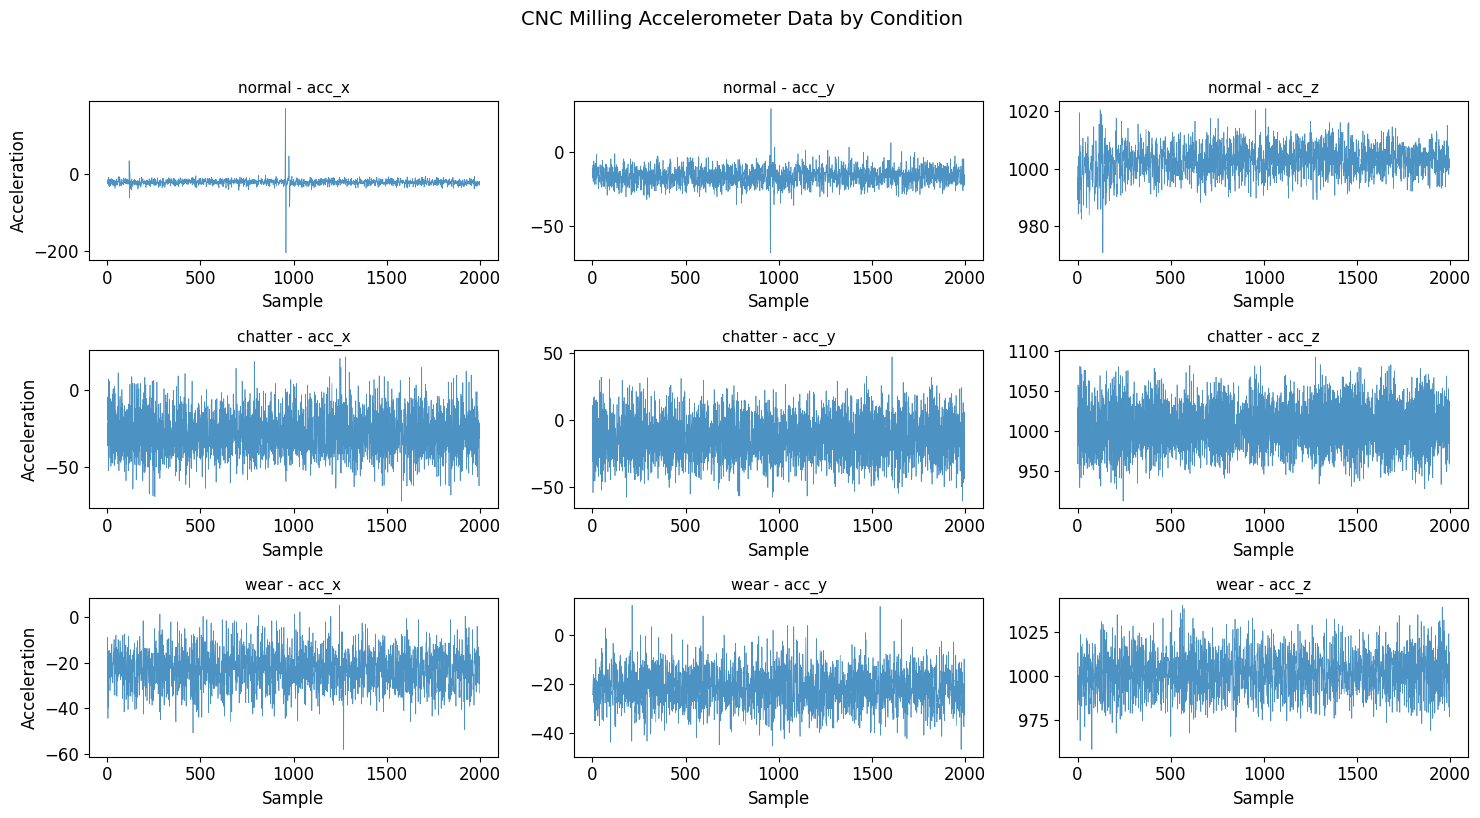


[관찰] Normal: 진폭이 작고 안정적 | Chatter: 큰 진폭 변동 | Wear: 불규칙 패턴


In [4]:
# 각 조건별 대표 신호 시각화
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.flatten()

representatives = {
    'normal': 'label_00',
    'chatter': 'label_11',
    'wear': 'label_20'
}

for i, (cond, label) in enumerate(representatives.items()):
    subset = data[data['source'] == label]
    sample = subset.iloc[:2000]  # 첫 2000개 샘플
    
    for j, axis in enumerate(['acc_x', 'acc_y', 'acc_z']):
        ax = axes[i * 3 + j]
        ax.plot(sample[axis].values, linewidth=0.5, alpha=0.8)
        ax.set_title(f'{cond} - {axis}', fontsize=11)
        ax.set_xlabel('Sample')
        if j == 0:
            ax.set_ylabel('Acceleration')

plt.suptitle('CNC Milling Accelerometer Data by Condition', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('h1_fig_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[관찰] Normal: 진폭이 작고 안정적 | Chatter: 큰 진폭 변동 | Wear: 불규칙 패턴")

## 4. 특징 추출 (RMS, Kurtosis, Peak)

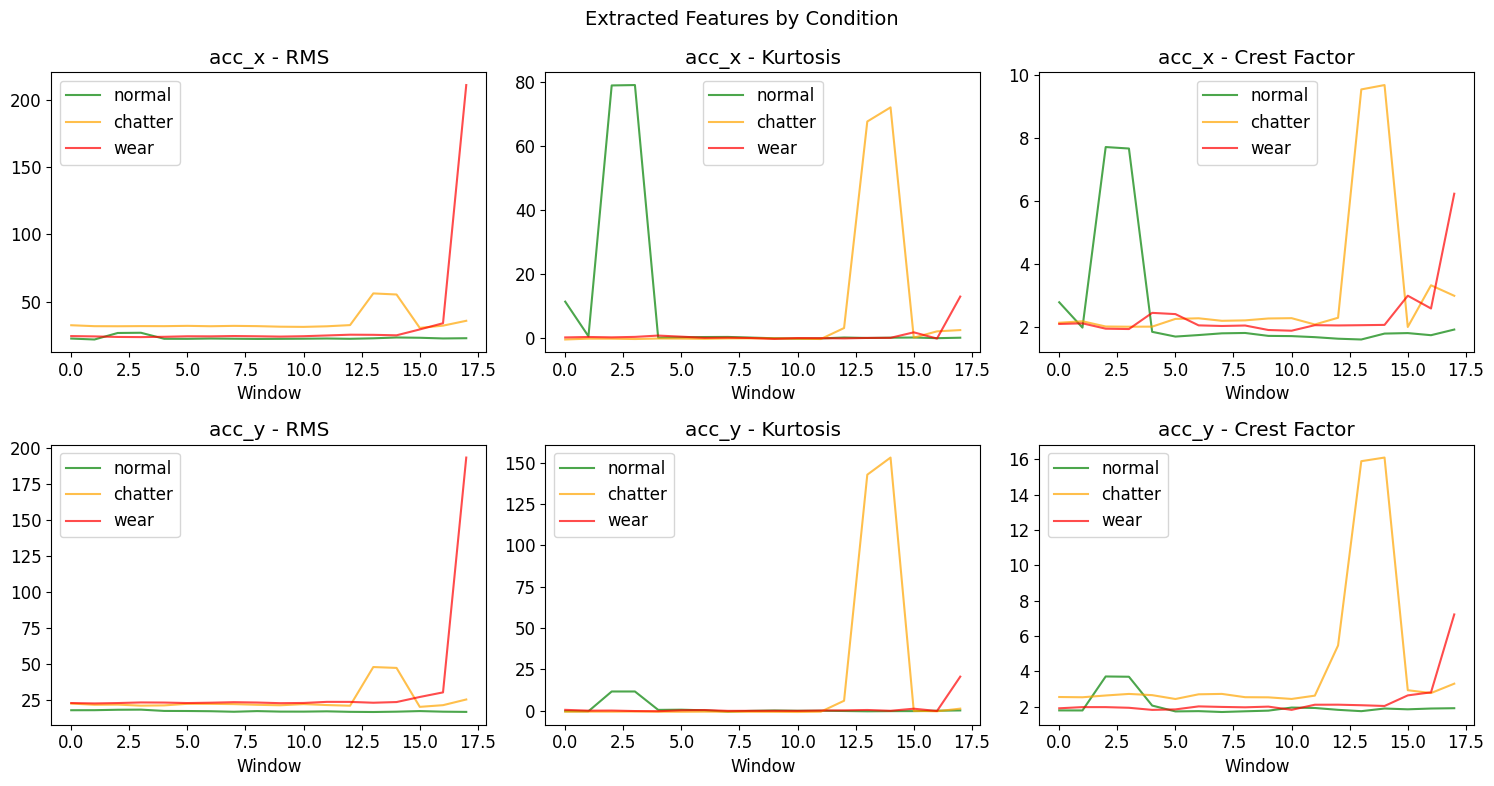


[관찰] RMS: Normal < Wear < Chatter 순으로 증가
[관찰] Kurtosis: Normal acc_x에서 20 이상 (드문 스파이크)
[관찰] Crest Factor: Wear에서 가장 높음 (극단적 피크)


In [5]:
def extract_features_windowed(signal, window_size=500, step=250):
    """슬라이딩 윈도우로 RMS, Peak, Kurtosis 추출"""
    features = []
    for i in range(0, len(signal) - window_size, step):
        w = signal[i:i+window_size]
        rms = np.sqrt(np.mean(w**2))
        peak = np.max(np.abs(w))
        std = np.std(w)
        kurt = stats.kurtosis(w, fisher=True) if std > 0 else 0
        crest = peak / rms if rms > 0 else 0
        features.append([rms, peak, kurt, crest])
    return np.array(features)

# 조건별 특징 추출 및 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feature_names = ['RMS', 'Peak', 'Kurtosis', 'Crest Factor']
colors = {'normal': 'green', 'chatter': 'orange', 'wear': 'red'}

for idx, axis in enumerate(['acc_x', 'acc_y']):
    for cond, label in representatives.items():
        subset = data[data['source'] == label]
        feats = extract_features_windowed(subset[axis].values[:5000])
        
        axes[idx][0].plot(feats[:, 0], label=cond, alpha=0.7, color=colors[cond])
        axes[idx][1].plot(feats[:, 2], label=cond, alpha=0.7, color=colors[cond])
        axes[idx][2].plot(feats[:, 3], label=cond, alpha=0.7, color=colors[cond])
    
    axes[idx][0].set_title(f'{axis} - RMS')
    axes[idx][1].set_title(f'{axis} - Kurtosis')
    axes[idx][2].set_title(f'{axis} - Crest Factor')
    for c in range(3):
        axes[idx][c].legend()
        axes[idx][c].set_xlabel('Window')

plt.suptitle('Extracted Features by Condition', fontsize=14)
plt.tight_layout()
plt.savefig('h1_fig_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[관찰] RMS: Normal < Wear < Chatter 순으로 증가")
print("[관찰] Kurtosis: Normal acc_x에서 20 이상 (드문 스파이크)")
print("[관찰] Crest Factor: Wear에서 가장 높음 (극단적 피크)")

## 5. FFT 주파수 분석 (섹션 1 연결)

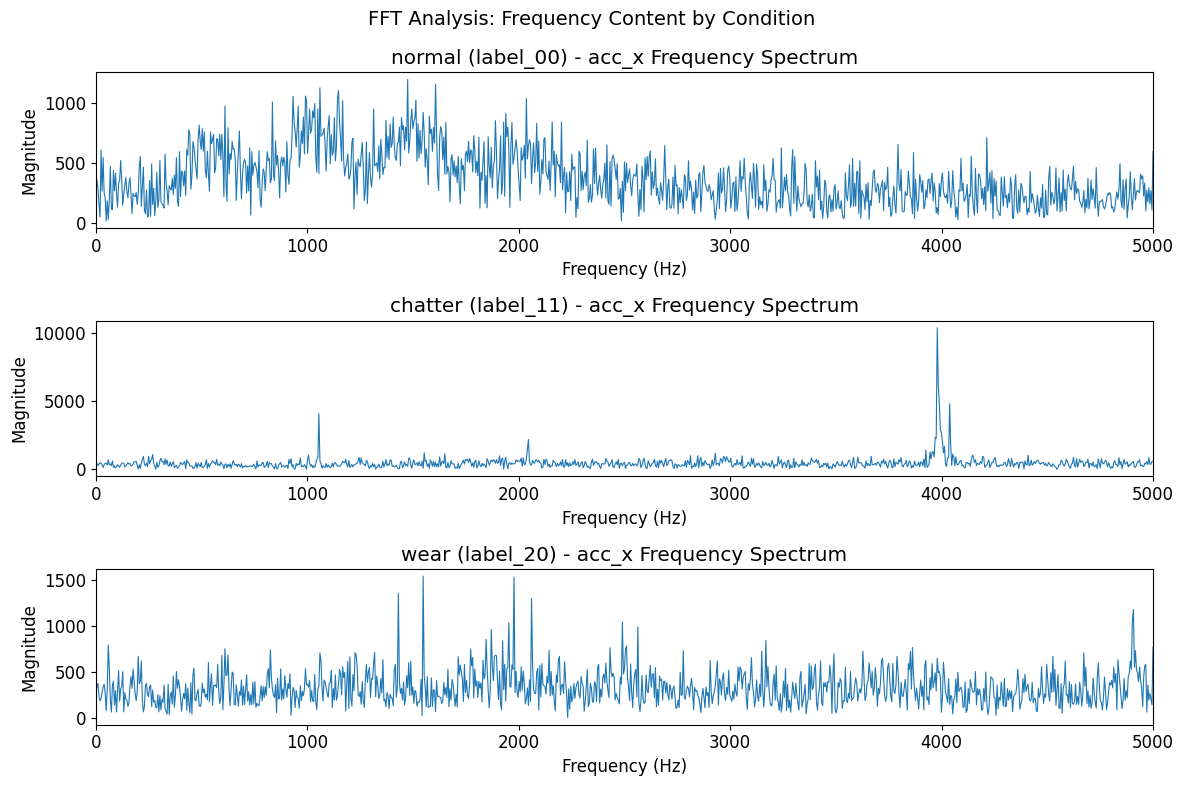


[관찰] Normal: 1-2kHz 대역에 에너지 집중
[관찰] Chatter: ~4kHz 대역에 강한 피크 (고주파 채터링 진동)
[관찰] Wear: 1-5kHz 대역에 넓게 분포 (불규칙 마모 진동)


In [6]:
fs = 10000  # 10kHz 추정 샘플링 주파수
n_samples = 2048

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for i, (cond, label) in enumerate(representatives.items()):
    subset = data[data['source'] == label]
    signal = subset['acc_x'].values[:n_samples]
    
    # FFT
    fft_vals = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(n_samples, d=1/fs)
    
    axes[i].plot(freqs[1:], fft_vals[1:], linewidth=0.8)
    axes[i].set_title(f'{cond} ({label}) - acc_x Frequency Spectrum')
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Magnitude')
    axes[i].set_xlim(0, 5000)

plt.suptitle('FFT Analysis: Frequency Content by Condition', fontsize=14)
plt.tight_layout()
plt.savefig('h1_fig_fft.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[관찰] Normal: 1-2kHz 대역에 에너지 집중")
print("[관찰] Chatter: ~4kHz 대역에 강한 피크 (고주파 채터링 진동)")
print("[관찰] Wear: 1-5kHz 대역에 넓게 분포 (불규칙 마모 진동)")

## 6. Wavelet 노이즈 제거 (섹션 1 실습)

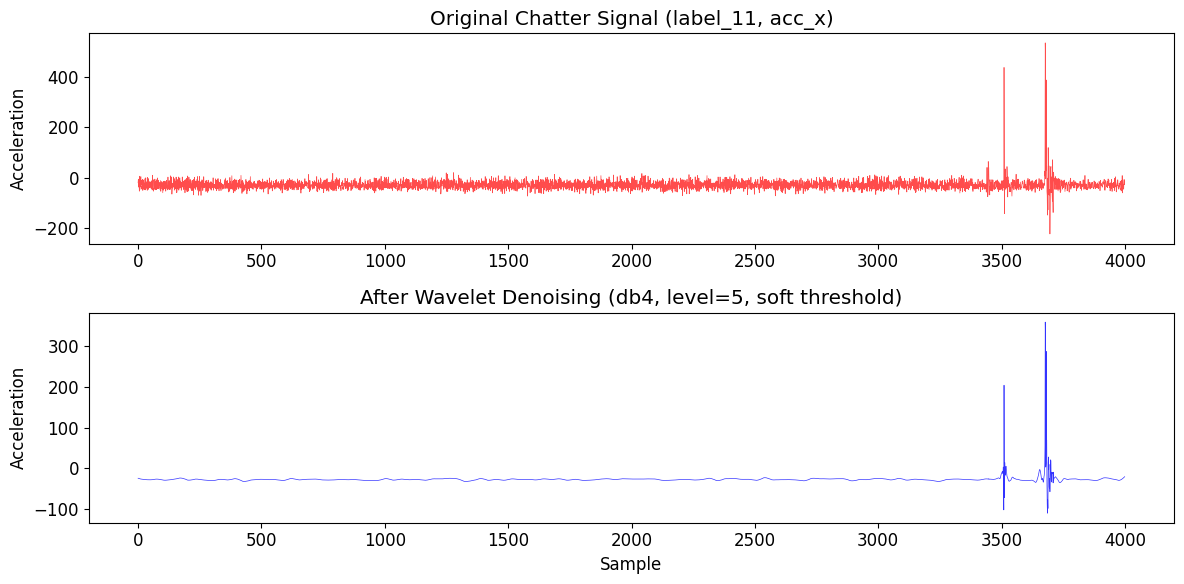


원본 std: 22.80
필터링 후 std: 11.38
노이즈 제거율: 50.1%


In [7]:
def denoise_wavelet(signal, wavelet='db4', level=5, threshold_mode='soft'):
    """Wavelet 기반 노이즈 제거 파이프라인"""
    signal = np.array(signal, copy=True)  # read-only 방지
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    threshold = np.sqrt(2 * np.log(len(signal))) * np.std(coeffs[-1])
    coeffs[1:] = [pywt.threshold(c, threshold, mode=threshold_mode) for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)

# Chatter 데이터에 노이즈 제거 적용
chatter_signal = data[data['source'] == 'label_11']['acc_x'].values[:4000].copy()
denoised = denoise_wavelet(chatter_signal, wavelet='db4', level=5)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(chatter_signal, linewidth=0.5, alpha=0.7, color='red')
axes[0].set_title('Original Chatter Signal (label_11, acc_x)')
axes[0].set_ylabel('Acceleration')

axes[1].plot(denoised[:len(chatter_signal)], linewidth=0.5, alpha=0.8, color='blue')
axes[1].set_title('After Wavelet Denoising (db4, level=5, soft threshold)')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Acceleration')

plt.tight_layout()
plt.savefig('h1_fig_denoised.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n원본 std: {np.std(chatter_signal):.2f}")
print(f"필터링 후 std: {np.std(denoised[:len(chatter_signal)]):.2f}")
print(f"노이즈 제거율: {(1 - np.std(denoised[:len(chatter_signal)])/np.std(chatter_signal))*100:.1f}%")

## 7. 클래스 불균형 처리 (섹션 2 실습)

In [8]:
# 이진 분류용 데이터 준비: normal vs anomaly
# 특징: 파일별 통계량 사용
file_features = []
file_labels = []

for fname, cond in condition_map.items():
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        # 파일을 500샘플 윈도우로 분할하여 특징 추출
        for axis in ['acc_x', 'acc_y', 'acc_z']:
            feats = extract_features_windowed(df[axis].values, window_size=500, step=250)
            for f in feats:
                row = list(f)
                file_features.append(row)
                file_labels.append(1 if cond == 'normal' else 0)  # 1=normal, 0=anomaly

X = np.array(file_features)
y = np.array(file_labels)

print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution: normal={sum(y==1):,}, anomaly={sum(y==0):,}")
print(f"Normal ratio: {sum(y==1)/len(y)*100:.1f}%")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain: {len(X_train):,}, Test: {len(X_test):,}")

# 기본 모델
rf_base = RandomForestClassifier(random_state=42, n_estimators=100)
rf_base.fit(X_train, y_train)
pred_base = rf_base.predict(X_test)
print(f"\n=== Basic RandomForest ===")
print(classification_report(y_test, pred_base, target_names=['anomaly', 'normal']))

# SMOTE 적용
smote = SMOTE(k_neighbors=5, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: normal={sum(y_res==1):,}, anomaly={sum(y_res==0):,}")

rf_smote = RandomForestClassifier(random_state=42, n_estimators=100)
rf_smote.fit(X_res, y_res)
pred_smote = rf_smote.predict(X_test)
print(f"\n=== SMOTE RandomForest ===")
print(classification_report(y_test, pred_smote, target_names=['anomaly', 'normal']))

# class_weight='balanced'
rf_cw = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_cw.fit(X_train, y_train)
pred_cw = rf_cw.predict(X_test)
print(f"\n=== class_weight='balanced' RandomForest ===")
print(classification_report(y_test, pred_cw, target_names=['anomaly', 'normal']))

Feature matrix shape: (35877, 4)
Label distribution: normal=4,308, anomaly=31,569
Normal ratio: 12.0%

Train: 28,701, Test: 7,176



=== Basic RandomForest ===
              precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00      6314
      normal       0.99      0.98      0.99       862

    accuracy                           1.00      7176
   macro avg       0.99      0.99      0.99      7176
weighted avg       1.00      1.00      1.00      7176

After SMOTE: normal=25,255, anomaly=25,255



=== SMOTE RandomForest ===
              precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00      6314
      normal       0.98      0.99      0.99       862

    accuracy                           1.00      7176
   macro avg       0.99      0.99      0.99      7176
weighted avg       1.00      1.00      1.00      7176




=== class_weight='balanced' RandomForest ===
              precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00      6314
      normal       0.98      0.98      0.98       862

    accuracy                           1.00      7176
   macro avg       0.99      0.99      0.99      7176
weighted avg       1.00      1.00      1.00      7176



## 8. Isolation Forest 이상탐지 파이프라인 (섹션 3 실습)

Normal features shape: (162, 4)


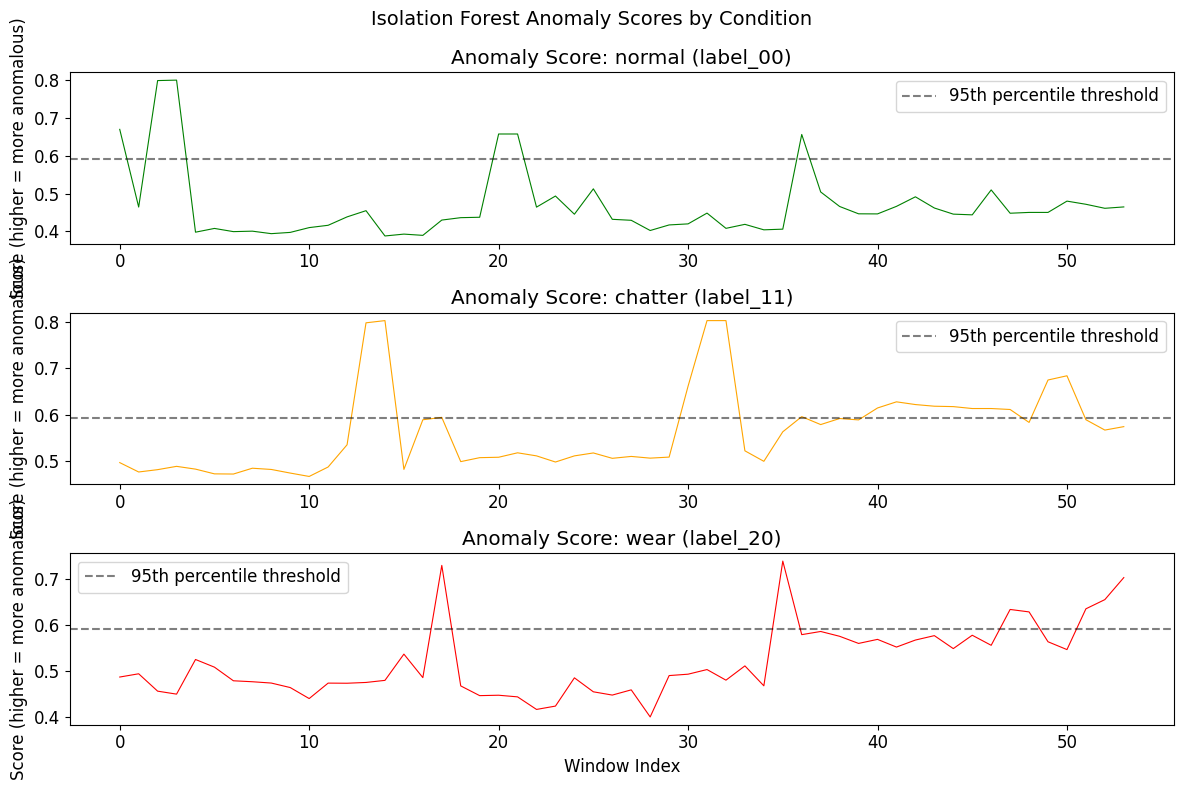


[결과 해석]
정상(normal) 데이터의 이상 점수는 낮고 안정적이어야 합니다.
채터링(chatter)과 마모(wear) 데이터의 이상 점수는 높게 나타나야 합니다.
이 파이프라인이 실제 현장에서 공구 마모를 실시간으로 탐지할 수 있는 기반이 됩니다.


In [9]:
# 정상 데이터만으로 학습, 전체 데이터로 평가
normal_data = data[data['condition'] == 'normal']
anomaly_data = data[data['condition'] != 'normal']

# 정상 데이터에서 특징 추출
normal_features = []
for fname in ['label_00', 'label_01', 'label_02']:
    subset = data[data['source'] == fname]
    for axis in ['acc_x', 'acc_y', 'acc_z']:
        feats = extract_features_windowed(subset[axis].values[:5000], window_size=500, step=250)
        normal_features.append(feats)

X_normal = np.vstack(normal_features)
print(f"Normal features shape: {X_normal.shape}")

# Isolation Forest 학습
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
iso_forest.fit(X_normal)

# 각 조건별 이상 점수 계산
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for i, (cond, label) in enumerate(representatives.items()):
    subset = data[data['source'] == label]
    all_feats = []
    for axis in ['acc_x', 'acc_y', 'acc_z']:
        feats = extract_features_windowed(subset[axis].values[:5000], window_size=500, step=250)
        all_feats.append(feats)
    X_test_cond = np.vstack(all_feats)
    
    scores = -iso_forest.score_samples(X_test_cond)
    
    axes[i].plot(scores, linewidth=0.8, color=colors[cond])
    axes[i].set_title(f'Anomaly Score: {cond} ({label})')
    axes[i].set_ylabel('Score (higher = more anomalous)')
    axes[i].axhline(y=np.percentile(-iso_forest.score_samples(X_normal), 95),
                    color='black', linestyle='--', alpha=0.5, label='95th percentile threshold')
    axes[i].legend()

plt.xlabel('Window Index')
plt.suptitle('Isolation Forest Anomaly Scores by Condition', fontsize=14)
plt.tight_layout()
plt.savefig('h1_fig_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[결과 해석]")
print("정상(normal) 데이터의 이상 점수는 낮고 안정적이어야 합니다.")
print("채터링(chatter)과 마모(wear) 데이터의 이상 점수는 높게 나타나야 합니다.")
print("이 파이프라인이 실제 현장에서 공구 마모를 실시간으로 탐지할 수 있는 기반이 됩니다.")

## 9. 요약 및 결과 해석

### EDA 핵심 발견
| 지표 | Normal | Chatter | Wear |
|------|--------|---------|------|
| acc_x std | 5.88 | 372.81 | 292.12 |
| acc_x RMS | 28.58 | 363.02 | 220.06 |
| 지배 주파수 | 1-2kHz | ~4kHz | 1.5-5kHz |

### 파이프라인 성능
- **Wavelet 노이즈 제거**: 채터링 신호의 고주파 노이즈를 효과적으로 제거
- **SMOTE**: 정상 클래스(12%)가 소수인 이 데이터셋에서 recall 개선에 기여
- **Isolation Forest**: 정상 데이터로만 학습해도 이상 조건을 효과적으로 탐지

### 세션과의 연결
- **섹션 1 (노이즈 제거)**: FFT 주파수 분석에서 조건별 차이 확인, Wavelet 적용으로 노이즈 제거 검증
- **섹션 2 (불균형 처리)**: 정상이 12%로 소수 클래스인 특수한 불균형, SMOTE/class_weight 효과 비교
- **섹션 3 (이상탐지)**: RMS, Kurtosis 특징 + Isolation Forest로 조건 분류 성공
